<a href="https://colab.research.google.com/github/McWooden/praktikum-struktur-data/blob/main/Dijkstras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Algoritma Dijkstra dengan Pelacakan Jalur

In [1]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt

def dijkstra_with_paths(graph, start):
    distances = {node: float('inf') for node in graph}
    distances[start] = 0
    previous = {node: None for node in graph}
    queue = [(0, start)]

    while queue:
        current_distance, current_node = heapq.heappop(queue)

        for neighbor, weight in graph[current_node].items():
            distance = current_distance + weight
            if distance < distances[neighbor]:
                distances[neighbor] = distance
                previous[neighbor] = current_node
                heapq.heappush(queue, (distance, neighbor))

    return distances, previous

# Rekonstruksi Jalur

In [2]:
def get_path(previous, target):
    path = []
    while target is not None:
        path.insert(0, target)
        target = previous[target]
    return path

# Visualisasi dengan NetworkX & Matplotlib

In [3]:
def visualize_graph(graph, path=None):
    G = nx.DiGraph()

    for node in graph:
        for neighbor, weight in graph[node].items():
            G.add_edge(node, neighbor, weight=weight)

    pos = nx.spring_layout(G)
    edge_labels = nx.get_edge_attributes(G, 'weight')

    plt.figure(figsize=(8, 6))
    nx.draw(G, pos, with_labels=True, node_color='lightblue',
            node_size=2000, font_weight='bold', arrows=True)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

    if path and len(path) > 1:
        path_edges = list(zip(path, path[1:]))
        nx.draw_networkx_edges(G, pos, edgelist=path_edges,
                               edge_color='red', width=3)

    plt.title("Visualisasi Graf dan Jalur Terpendek")
    plt.axis('off')
    plt.show()

# Penggunaan Lengkap

Jarak dari A ke Z: 14
Jalur: A -> B -> D -> E -> Z


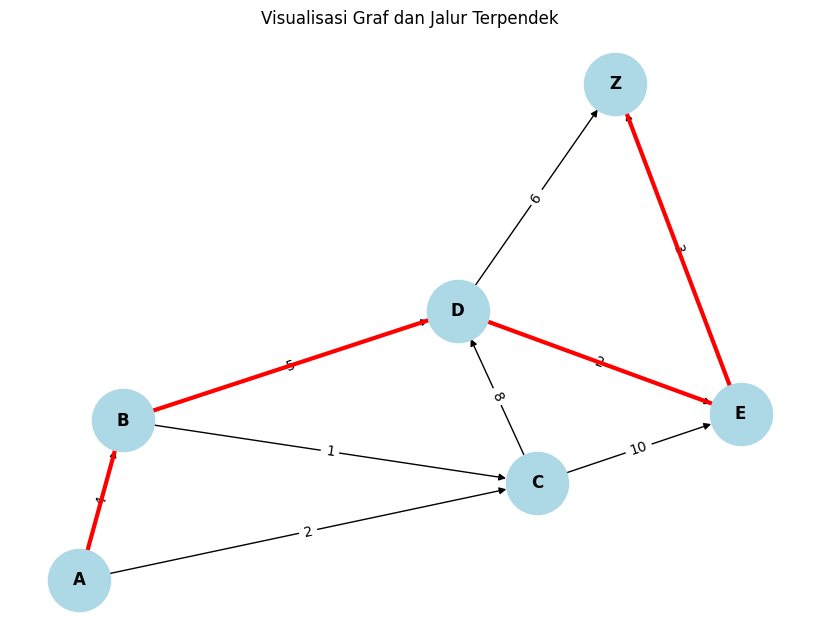

In [5]:
# Definisi graf
graph = {
    'A': {'B': 4, 'C': 2},
    'B': {'C': 1, 'D': 5},
    'C': {'D': 8, 'E': 10},
    'D': {'E': 2, 'Z': 6},
    'E': {'Z': 3},
    'Z': {}
}

# Jalankan Dijkstra
start_node = 'A'
end_node = 'Z'
distances, previous = dijkstra_with_paths(graph, start_node)

# Rekonstruksi jalur
shortest_path = get_path(previous, end_node)
print(f"Jarak dari {start_node} ke {end_node}: {distances[end_node]}")
print(f"Jalur: {' -> '.join(shortest_path)}")

# Visualisasi
visualize_graph(graph, path=shortest_path)

# Latihan Personal

In [7]:
distances, previous = dijkstra_with_paths(graph, 'A')

print("=== Jarak Terpendek dari A ke semua simpul ===")
for node, dist in sorted(distances.items()):
    path = get_path(previous, node)
    path_str = ' → '.join(path)
    print(f"  A → {node}: {dist:>3}  |  Jalur: {path_str}")

=== Jarak Terpendek dari A ke semua simpul ===
  A → A:   0  |  Jalur: A
  A → B:   4  |  Jalur: A → B
  A → C:   2  |  Jalur: A → C
  A → D:   9  |  Jalur: A → B → D
  A → E:  11  |  Jalur: A → B → D → E
  A → Z:  14  |  Jalur: A → B → D → E → Z


# Tugas 1 - Graf dengan Siklus

Jarak dari A ke Z: 14
Jalur: A -> B -> D -> E -> Z


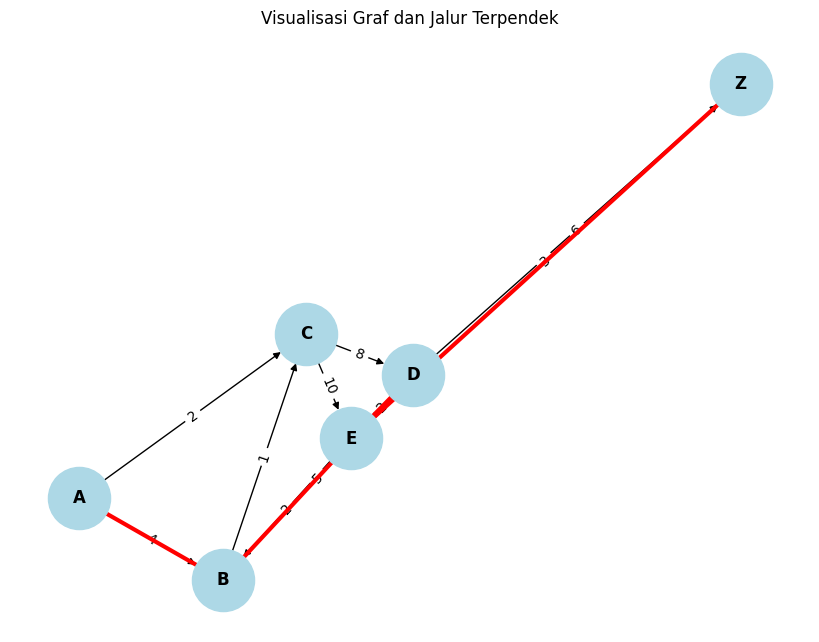

In [15]:
graph = {
    'A': {'B': 4, 'C': 2},
    'B': {'C': 1, 'D': 5},
    'C': {'D': 8, 'E': 10},
    'D': {'E': 2, 'Z': 6},
    'E': {'Z': 3, 'B': 2},  # Membentuk siklus E -> B
    'Z': {}
}

start_node = 'A'
end_node = 'Z'

distances, previous = dijkstra_with_paths(graph, start_node)

shortest_path = get_path(previous, end_node)

print(f"Jarak dari {start_node} ke {end_node}: {distances[end_node]}")
print(f"Jalur: {' -> '.join(shortest_path)}")

visualize_graph(graph, path=shortest_path)

# Tugas 2 - Tambah Simpul Baru

Jarak dari A ke Z: 11
Jalur: A -> B -> D -> F -> Z


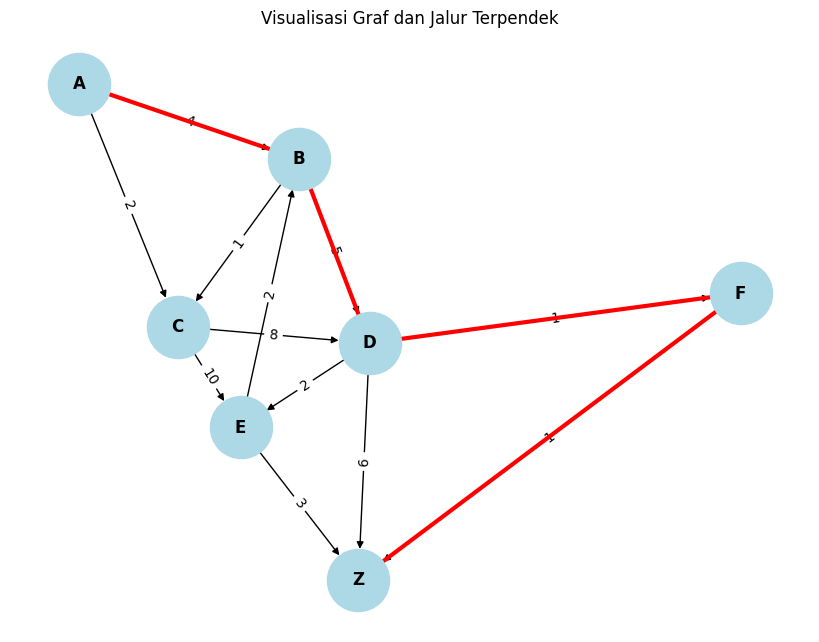

In [16]:
graph = {
    'A': {'B': 4, 'C': 2},
    'B': {'C': 1, 'D': 5},
    'C': {'D': 8, 'E': 10},
    'D': {'E': 2, 'F': 1, 'Z': 6},
    'E': {'Z': 3, 'B': 2},
    'F': {'Z': 1},
    'Z': {}
}

start_node = 'A'
end_node = 'Z'

distances, previous = dijkstra_with_paths(graph, start_node)

shortest_path = get_path(previous, end_node)

print(f"Jarak dari {start_node} ke {end_node}: {distances[end_node]}")
print(f"Jalur: {' -> '.join(shortest_path)}")

visualize_graph(graph, path=shortest_path)

# Tugas 3 - Ganti Layout

Jarak dari A ke Z: 11
Jalur: A -> B -> D -> F -> Z


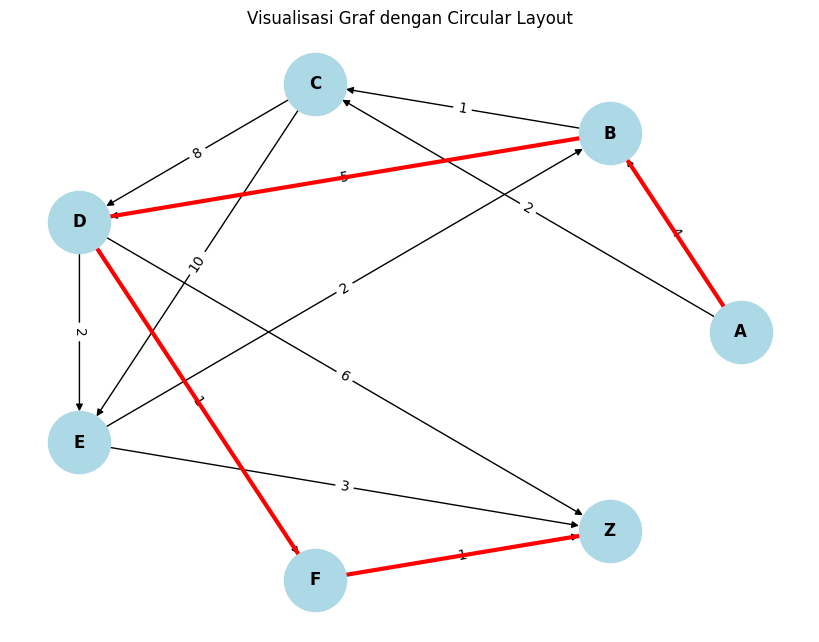

In [22]:
# Data graph dari Tugas 2
graph = {
    'A': {'B': 4, 'C': 2},
    'B': {'C': 1, 'D': 5},
    'C': {'D': 8, 'E': 10},
    'D': {'E': 2, 'F': 1, 'Z': 6},
    'E': {'Z': 3, 'B': 2},
    'F': {'Z': 1},
    'Z': {}
}

# Jalankan Dijkstra
start_node = 'A'
end_node = 'Z'

distances, previous = dijkstra_with_paths(graph, start_node)
shortest_path = get_path(previous, end_node)

print(f"Jarak dari {start_node} ke {end_node}: {distances[end_node]}")
print(f"Jalur: {' -> '.join(shortest_path)}")


# Visualisasi khusus Tugas 3 (Circular Layout)
G = nx.DiGraph()

for node in graph:
    for neighbor, weight in graph[node].items():
        G.add_edge(node, neighbor, weight=weight)

pos = nx.circular_layout(G)

edge_labels = nx.get_edge_attributes(G, 'weight')

plt.figure(figsize=(8, 6))

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color='lightblue',
    node_size=2000,
    font_weight='bold',
    arrows=True
)

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels
)

path_edges = list(zip(shortest_path, shortest_path[1:]))

nx.draw_networkx_edges(
    G,
    pos,
    edgelist=path_edges,
    edge_color='red',
    width=3
)

plt.title("Visualisasi Graf dengan Circular Layout")
plt.axis('off')
plt.show()